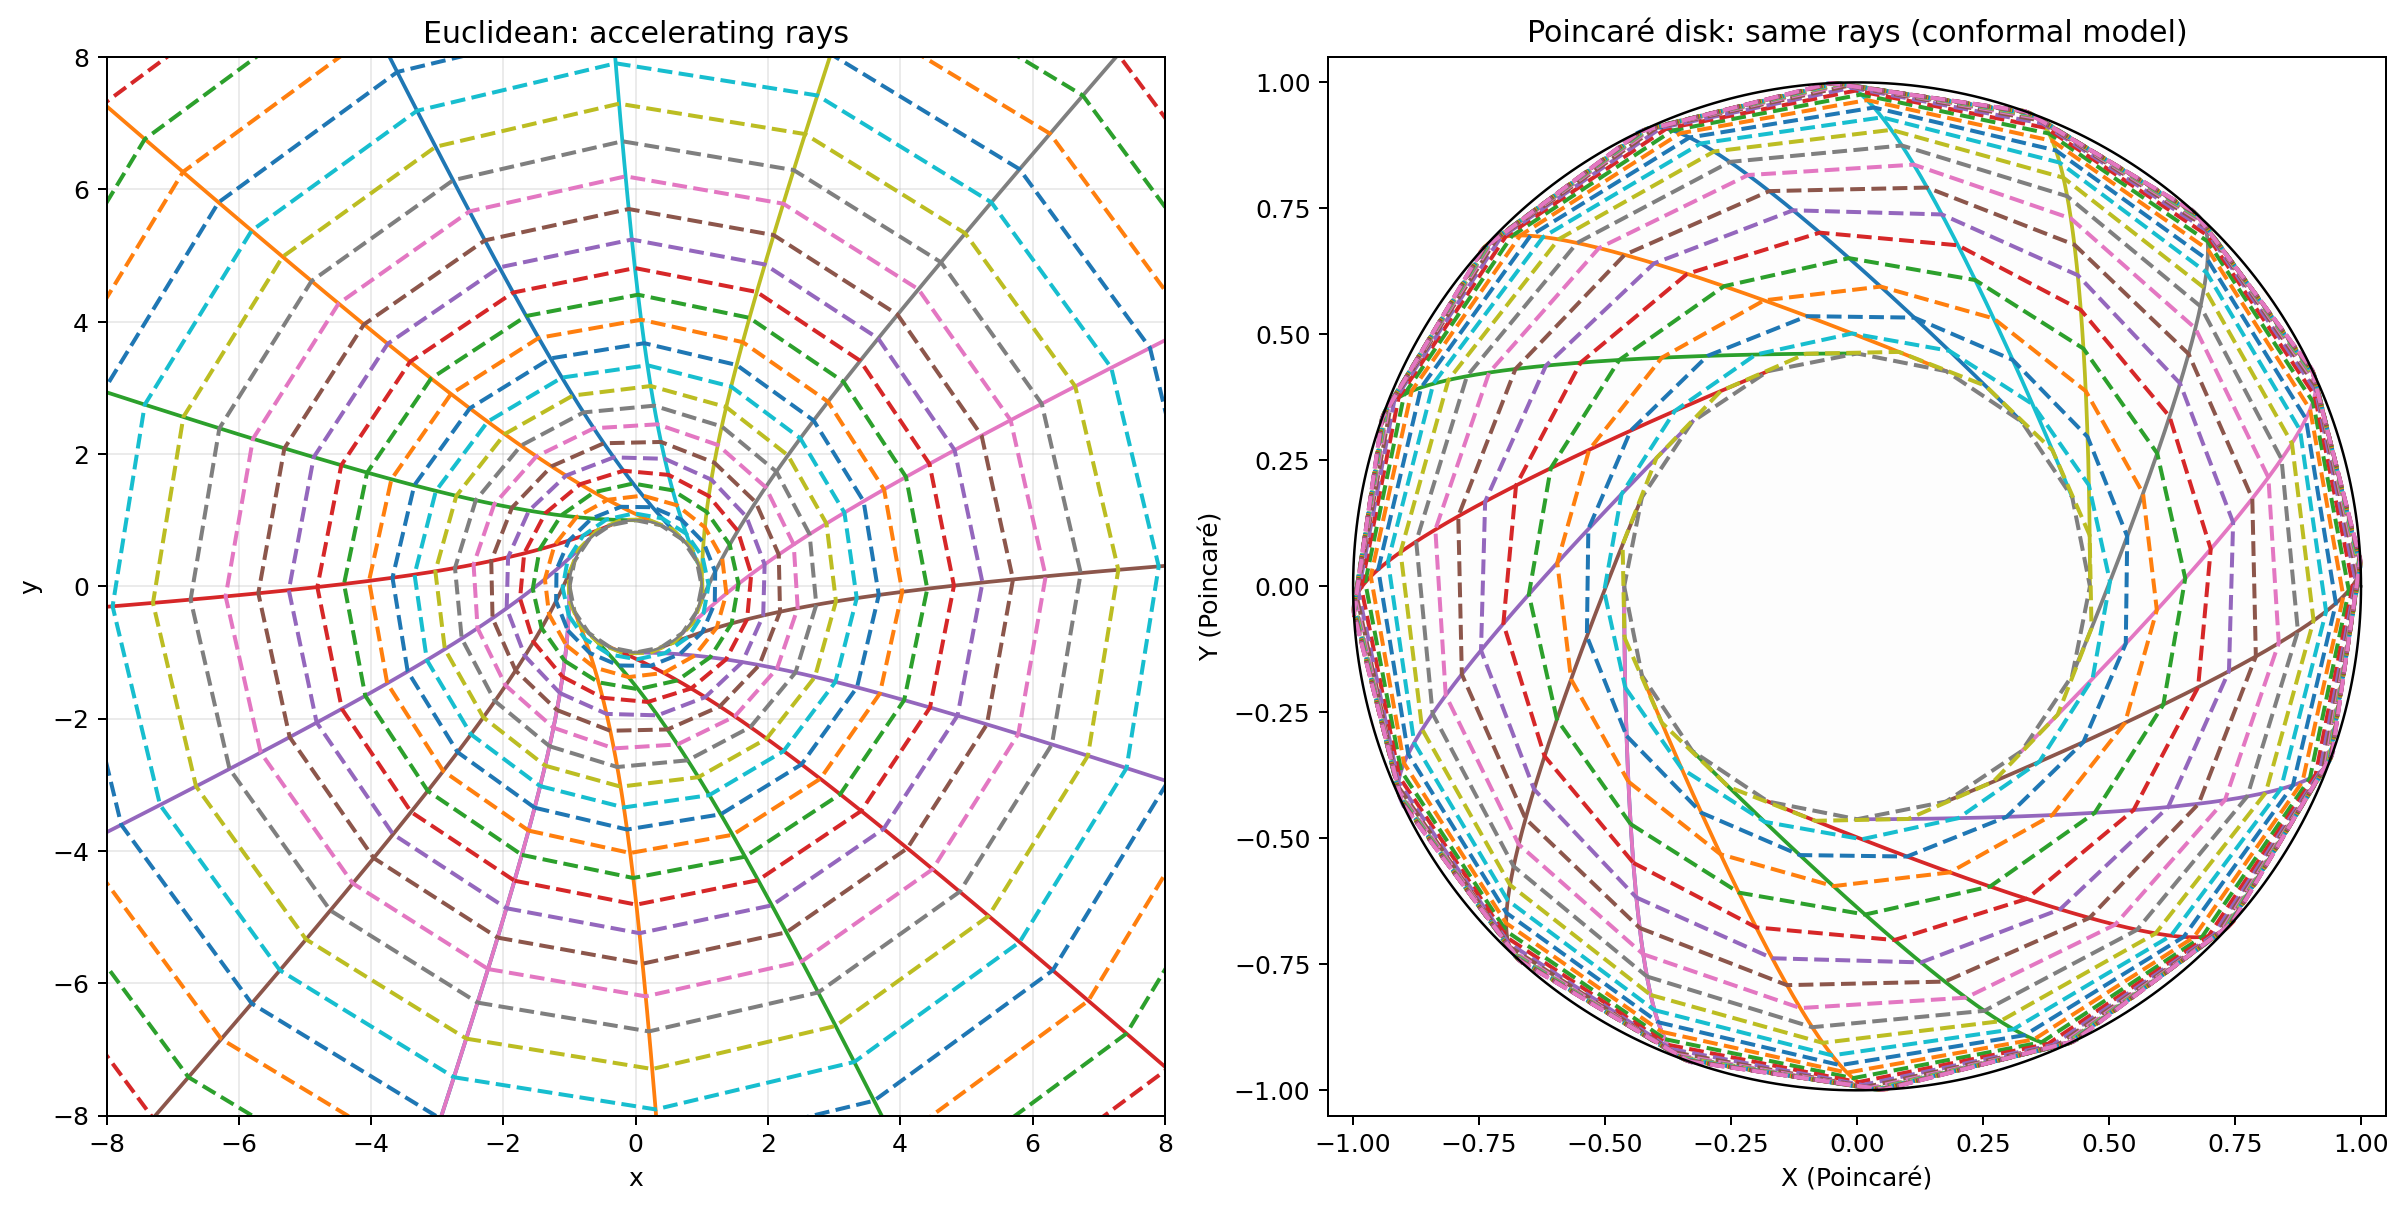

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters (tweakable)
omega = 1.0          # sets the "hyperbolic" (repulsive) acceleration scale
L = 2.9              # constant angular momentum for all rays
t_max = 2.6          # integrate long enough that rays accelerate outward
n_rays = 17          # number of rays (starting points along the unit circle)
phi_span = (np.deg2rad(-180), np.deg2rad(180))  # sector of start angles on unit circle

# ODE in polar coordinates:
# r'' = omega^2 r + L^2/r^3  (repulsive inverted harmonic + centrifugal term)
# theta' = L/r^2            (constant angular momentum)
def ode(t, y):
    r, vr, th = y
    dr = vr
    dvr = omega**2 * r + (L**2) / (r**3)
    dth = L / (r**2)
    return [dr, dvr, dth]

# Poincare disk mapping: (x, y) in R^2 -> (X, Y) in unit disk via s = tanh(r/2)
def poincare_map(r, th):
    s = np.tanh(r / 2)
    X = s * np.cos(th)
    Y = s * np.sin(th)
    return X, Y

# Integrate each ray
phis = np.linspace(phi_span[0], phi_span[1], n_rays)
sols = []
for phi0 in phis:
    y0 = [1.0, 0.0, phi0]  # start on unit circle, zero radial velocity, angle = phi0
    sol = solve_ivp(ode, (0, t_max), y0, dense_output=True, rtol=1e-9, atol=1e-12)
    sols.append(sol)

# Prepare figure with two subplots
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 7.2), dpi=180)
fig.subplots_adjust(wspace=0.24)

# -----------------------------
# Euclidean subplot (left)
# -----------------------------
# Rays
t_grid = np.linspace(0, t_max, 9000)
for sol in sols:
    r, vr, th = sol.sol(t_grid)
    x = r * np.cos(th)
    y = r * np.sin(th)
    ax.plot(x, y, linewidth=1.5)

# Wavefronts: connect equal-time points across rays
wave_times = np.linspace(0., 2.2, 30)
for tw in wave_times:
    xs, ys = [], []
    for sol in sols:
        r, vr, th = sol.sol(tw)
        xs.append(r * np.cos(th))
        ys.append(r * np.sin(th))
    ax.plot(xs, ys, linestyle="--", linewidth=1.6)

# Reference: unit circle start
th0 = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(th0), np.sin(th0), linewidth=1.0)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Euclidean: accelerating rays")
ax.grid(True, alpha=0.25)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)

# -----------------------------
# Poincare disk subplot (right)
# -----------------------------
# Rays in Poincare disk
for sol in sols:
    r, vr, th = sol.sol(t_grid)
    X, Y = poincare_map(r, th)
    ax2.plot(X, Y, linewidth=1.5)

# Wavefronts in Poincare disk
for tw in wave_times:
    Xs, Ys = [], []
    for sol in sols:
        r, vr, th = sol.sol(tw)
        x, y = pon = poincare_map(r, th)
        Xs.append(x)
        Ys.append(y)
    ax2.plot(Xs, Ys, linestyle="--", linewidth=1.6)

# Disk boundary
th0 = np.linspace(0, 2*np.pi, 400)
ax2.plot(np.cos(th0), np.sin(th0), color='k', linewidth=1.0)
ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel("X (Poincaré)")
ax2.set_ylabel("Y (Poincaré)")
ax2.set_title("Poincaré disk: same rays (conformal model)")
ax2.set_xlim(-1.05, 1.05)
ax2.set_ylim(-1.05, 1.05)

# Optional: faded interior circle for visual context
ax2.fill(np.cos(th0), np.sin(th0), color="#eeeeee", alpha=0.09, linewidth=0)

plt.tight_layout()
plt.show()

In [ ]:
"""
Characteristic “rays” in x ∈ R^2 for a Kuramoto-type continuity equation.

We visualize characteristics of the *first-order* flow
    x'(t) = ω  -  K * F(x)
with ω constant along each path (as in your kinetic model), and an illustrative
mean-field force F(x). Two options are provided:

1) model="singular_centered":
       F(x) ≈ (1/(1-α)) * x / |x|^α
   (this mimics ∇W(x) for W(x) ∝ |x|^{2-α}, assuming the x-marginal is centered near 0)

2) model="quadratic_centered":
       F(x) = x
   (the α=0 “quadratic” case; yields linear relaxation toward the origin)

The code draws:
- rays (trajectories starting on a circle)
- wavefronts (equal-time curves across rays), like your example.

If ipywidgets is available, you’ll get a Jupyter widget UI.
Otherwise, it falls back to matplotlib Sliders (works best in an interactive backend).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Core characteristic dynamics
# -----------------------------
def force_F(xy, model="singular_centered", alpha=0.5, eps=1e-6):
    """
    Return F(x) in x'(t) = ω - K F(x).
    """
    x, y = xy
    if model == "quadratic_centered":
        return np.array([x, y], dtype=float)

    # model == "singular_centered"
    r = np.hypot(x, y)
    # regularize near r=0 to avoid blow-up
    denom = (r**alpha + eps)
    # mimics ∇W(x) = (1/(1-α)) * x/|x|^α
    return (1.0 / (1.0 - alpha)) * np.array([x, y], dtype=float) / denom


def integrate_rays(
    K=1.0,
    alpha=0.4,
    omega_mag=1.2,
    omega_twist=0.0,   # adds tangential component to ω
    t_max=3.0,
    n_rays=17,
    r0=1.0,
    phi_span=(-np.pi, np.pi),
    model="singular_centered",
    eps=1e-6,
    rtol=1e-8,
    atol=1e-10,
):
    """
    Integrate a family of rays starting on the circle of radius r0.
    Each ray has constant ω determined by its start angle:
        ω = omega_mag * e_r  + omega_twist * e_theta
    """
    phis = np.linspace(phi_span[0], phi_span[1], n_rays)
    sols = []

    for phi0 in phis:
        x0 = r0 * np.array([np.cos(phi0), np.sin(phi0)], dtype=float)

        # radial + tangential constant ω (so rays can spiral if omega_twist != 0)
        e_r = np.array([np.cos(phi0), np.sin(phi0)], dtype=float)
        e_th = np.array([-np.sin(phi0), np.cos(phi0)], dtype=float)
        omega = omega_mag * e_r + omega_twist * e_th

        def ode(t, y):
            # y = (x, y) in R^2
            F = force_F(y, model=model, alpha=alpha, eps=eps)
            return omega - K * F

        sol = solve_ivp(
            ode,
            (0.0, t_max),
            x0,
            dense_output=True,
            rtol=rtol,
            atol=atol,
        )
        sols.append(sol)

    return phis, sols


def plot_rays_and_wavefronts(
    K=1.0,
    alpha=0.4,
    omega_mag=1.2,
    omega_twist=0.0,
    t_max=3.0,
    n_rays=17,
    n_wavefronts=30,
    wave_t_max=None,
    r0=1.0,
    phi_span=(-np.pi, np.pi),
    model="singular_centered",
    xlim=(-8, 8),
    ylim=(-8, 8),
):
    if wave_t_max is None:
        wave_t_max = 0.85 * t_max

    phis, sols = integrate_rays(
        K=K,
        alpha=alpha,
        omega_mag=omega_mag,
        omega_twist=omega_twist,
        t_max=t_max,
        n_rays=n_rays,
        r0=r0,
        phi_span=phi_span,
        model=model,
    )

    fig, ax = plt.subplots(figsize=(7.2, 7.2), dpi=160)

    # Rays
    t_grid = np.linspace(0.0, t_max, 900)
    for sol in sols:
        xy = sol.sol(t_grid)  # shape (2, len(t_grid))
        ax.plot(xy[0], xy[1], linewidth=1.5)

    # Wavefronts: connect equal-time points across rays
    wave_times = np.linspace(0.0, wave_t_max, n_wavefronts)
    for tw in wave_times:
        xs, ys = [], []
        for sol in sols:
            xy = sol.sol(tw)
            xs.append(xy[0])
            ys.append(xy[1])
        ax.plot(xs, ys, linestyle="--", linewidth=1.4)

    # Reference: start circle
    th0 = np.linspace(0, 2 * np.pi, 400)
    ax.plot(r0 * np.cos(th0), r0 * np.sin(th0), linewidth=1.0)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(
        f"Characteristics in $\\mathbb{{R}}^2$:  x'(t)=ω-KF(x)\n"
        f"model={model},  K={K:.3g},  α={alpha:.3g},  |ω|≈{omega_mag:.3g},  twist={omega_twist:.3g}"
    )
    ax.grid(True, alpha=0.25)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Widget / interactive UI
# -----------------------------
def characteristic_widget():
    """
    If ipywidgets is available: interactive sliders in Jupyter.
    Otherwise: matplotlib Sliders (requires an interactive backend).
    """
    try:
        import ipywidgets as widgets
        from ipywidgets import interactive_output

        K = widgets.FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.05, description="K")
        alpha = widgets.FloatSlider(value=0.4, min=0.0, max=0.95, step=0.01, description="alpha")
        omega_mag = widgets.FloatSlider(value=1.2, min=0.0, max=4.0, step=0.05, description="|omega|")
        omega_twist = widgets.FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.05, description="twist")
        t_max = widgets.FloatSlider(value=3.0, min=0.5, max=8.0, step=0.1, description="t_max")
        n_rays = widgets.IntSlider(value=17, min=5, max=61, step=2, description="n_rays")
        n_wf = widgets.IntSlider(value=30, min=5, max=60, step=1, description="wavefronts")
        model = widgets.Dropdown(
            options=["singular_centered", "quadratic_centered"],
            value="singular_centered",
            description="model",
        )

        ui = widgets.VBox([
            widgets.HBox([model, K, alpha]),
            widgets.HBox([omega_mag, omega_twist, t_max]),
            widgets.HBox([n_rays, n_wf]),
        ])

        out = interactive_output(
            lambda model, K, alpha, omega_mag, omega_twist, t_max, n_rays, n_wf: plot_rays_and_wavefronts(
                model=model,
                K=K,
                alpha=alpha,
                omega_mag=omega_mag,
                omega_twist=omega_twist,
                t_max=t_max,
                n_rays=n_rays,
                n_wavefronts=n_wf,
                xlim=(-10, 10),
                ylim=(-10, 10),
            ),
            dict(
                model=model,
                K=K,
                alpha=alpha,
                omega_mag=omega_mag,
                omega_twist=omega_twist,
                t_max=t_max,
                n_rays=n_rays,
                n_wf=n_wf,
            ),
        )

        display(ui, out)
        return

    except Exception:
        # Fallback: matplotlib slider UI
        from matplotlib.widgets import Slider, RadioButtons

        # NOTE: For best results in Jupyter, enable an interactive backend, e.g.:
        #   %matplotlib widget
        # or run in a desktop backend (QtAgg / TkAgg).

        init = dict(K=1.0, alpha=0.4, omega_mag=1.2, omega_twist=0.0, t_max=3.0, model="singular_centered")
        n_rays = 17
        n_wf = 30

        fig, ax = plt.subplots(figsize=(7.2, 7.2), dpi=140)
        plt.subplots_adjust(left=0.25, bottom=0.25)

        def draw(params):
            ax.cla()
            phis, sols = integrate_rays(
                K=params["K"],
                alpha=params["alpha"],
                omega_mag=params["omega_mag"],
                omega_twist=params["omega_twist"],
                t_max=params["t_max"],
                n_rays=n_rays,
                model=params["model"],
            )
            t_grid = np.linspace(0.0, params["t_max"], 700)
            for sol in sols:
                xy = sol.sol(t_grid)
                ax.plot(xy[0], xy[1], linewidth=1.4)

            wave_times = np.linspace(0.0, 0.85 * params["t_max"], n_wf)
            for tw in wave_times:
                xs, ys = [], []
                for sol in sols:
                    xy = sol.sol(tw)
                    xs.append(xy[0]); ys.append(xy[1])
                ax.plot(xs, ys, linestyle="--", linewidth=1.2)

            th0 = np.linspace(0, 2*np.pi, 400)
            ax.plot(np.cos(th0), np.sin(th0), linewidth=1.0)

            ax.set_aspect("equal", adjustable="box")
            ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
            ax.grid(True, alpha=0.25)
            ax.set_title(
                f"x'(t)=ω-KF(x)  | model={params['model']}  "
                f"K={params['K']:.2f}  α={params['alpha']:.2f}  "
                f"|ω|={params['omega_mag']:.2f}  twist={params['omega_twist']:.2f}"
            )
            ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

        draw(init)

        # Sliders axes
        axK = plt.axes([0.25, 0.15, 0.65, 0.03])
        axA = plt.axes([0.25, 0.11, 0.65, 0.03])
        axO = plt.axes([0.25, 0.07, 0.65, 0.03])
        axT = plt.axes([0.25, 0.03, 0.65, 0.03])
        axTw = plt.axes([0.25, 0.19, 0.65, 0.03])

        sK = Slider(axK, "K", -3.0, 3.0, valinit=init["K"], valstep=0.05)
        sA = Slider(axA, "alpha", 0.0, 0.95, valinit=init["alpha"], valstep=0.01)
        sO = Slider(axO, "|omega|", 0.0, 4.0, valinit=init["omega_mag"], valstep=0.05)
        sTw = Slider(axTw, "twist", -3.0, 3.0, valinit=init["omega_twist"], valstep=0.05)
        sT = Slider(axT, "t_max", 0.5, 8.0, valinit=init["t_max"], valstep=0.1)

        # Radio buttons for model
        rax = plt.axes([0.02, 0.70, 0.18, 0.20])
        radio = RadioButtons(rax, ("singular_centered", "quadratic_centered"), active=0)

        def update(_=None):
            params = dict(
                K=sK.val,
                alpha=sA.val,
                omega_mag=sO.val,
                omega_twist=sTw.val,
                t_max=sT.val,
                model=radio.value_selected,
            )
            draw(params)
            fig.canvas.draw_idle()

        sK.on_changed(update)
        sA.on_changed(update)
        sO.on_changed(update)
        sTw.on_changed(update)
        sT.on_changed(update)
        radio.on_clicked(lambda _: update())

        plt.show()


# ---- Run one static plot (optional)
# plot_rays_and_wavefronts()

# ---- Or start the widget UI:
characteristic_widget()

Output()